In [3]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from data_loader import load_train_data, load_test_data
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
# 训练集：2022-01~2023-02
X_trains, X_tests, y_trains, y_tests = [], [], [], []
for month in [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2024) for m in range(1, 13)]:
    if month >= "2023-03":
        break
    malicious_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/dataset/malware_features_{month}.txt"
    benign_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/dataset/benign_features_{month}.txt"
    X_train, X_test, y_train, y_test = load_train_data(malicious_output_txt_path, benign_output_txt_path)
    X_trains.append(X_train)
    X_tests.append(X_test)
    y_trains.append(y_train)
    y_tests.append(y_test)
X_train = np.vstack(X_trains)
y_train = np.hstack(y_trains)
X_test = np.vstack(X_tests)
y_test = np.hstack(y_tests)

In [5]:
from train_with_lime import train_with_progress_bar, load_sensitive_apis

sensitive_api_file = r"/Data2/hxq/MalGuard/API-call-graph/gpt_prompt_result_closeness.json"
with open(sensitive_api_file, "r") as f:
    sensitive_apis = json.load(f)
sensitive_apis = load_sensitive_apis(sensitive_api_file) 

model_save_path = r"./models"
os.makedirs(model_save_path, exist_ok=True)

# NB
nb_model = GaussianNB()
train_with_progress_bar(nb_model, X_train, y_train, X_test, y_test, "Naive Bayes", model_save_path,
                        sensitive_apis, n_iter=100)

# MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1, warm_start=True, random_state=42)
train_with_progress_bar(mlp_model, X_train, y_train, X_test, y_test, "Multi Layer Perceptron",
                        model_save_path, sensitive_apis, n_iter=500)

# RF
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_with_progress_bar(rf_model, X_train, y_train, X_test, y_test, "Random Forest", model_save_path,
                        sensitive_apis, n_iter=100)

# DT
dt_model = DecisionTreeClassifier(random_state=42)
train_with_progress_bar(dt_model, X_train, y_train, X_test, y_test, "Decision Tree", model_save_path,
                        sensitive_apis, n_iter=100)

Training Naive Bayes: 100%|██████████| 100/100 [00:00<00:00, 371.60iter/s]



Naive Bayes Results
              precision    recall  f1-score   support

         0.0    0.56979   0.98810   0.72279       252
         1.0    0.96970   0.33803   0.50131       284

    accuracy                        0.64366       536
   macro avg    0.76975   0.66306   0.61205       536
weighted avg    0.78168   0.64366   0.60543       536

Naive Bayes saved to ./models/naive_bayes/naive_bayes_model.pkl


Training Multi Layer Perceptron: 100%|██████████| 500/500 [00:09<00:00, 53.98iter/s]



Multi Layer Perceptron Results
              precision    recall  f1-score   support

         0.0    0.96047   0.96429   0.96238       252
         1.0    0.96820   0.96479   0.96649       284

    accuracy                        0.96455       536
   macro avg    0.96434   0.96454   0.96443       536
weighted avg    0.96457   0.96455   0.96456       536

Multi Layer Perceptron saved to ./models/multi_layer_perceptron/multi_layer_perceptron_model.pkl


Training Random Forest: 100%|██████████| 100/100 [00:20<00:00,  4.79iter/s]



Random Forest Results
              precision    recall  f1-score   support

         0.0    0.95703   0.97222   0.96457       252
         1.0    0.97500   0.96127   0.96809       284

    accuracy                        0.96642       536
   macro avg    0.96602   0.96674   0.96633       536
weighted avg    0.96655   0.96642   0.96643       536

Random Forest saved to ./models/random_forest/random_forest_model.pkl


Training Decision Tree: 100%|██████████| 100/100 [00:01<00:00, 81.03iter/s]


Decision Tree Results
              precision    recall  f1-score   support

         0.0    0.95635   0.95635   0.95635       252
         1.0    0.96127   0.96127   0.96127       284

    accuracy                        0.95896       536
   macro avg    0.95881   0.95881   0.95881       536
weighted avg    0.95896   0.95896   0.95896       536

Decision Tree saved to ./models/decision_tree/decision_tree_model.pkl


In [6]:
def test_model(model, X_test, y_test, model_name):
    """
    测试模型并打印 precision, recall, f1
    """
    print(f"\n{'='*50}")
    print(f"Testing {model_name}")
    print(f"{'='*50}")

    # 预测
    y_pred = model.predict(X_test)

    # 计算指标
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # 打印结果
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    # 详细分类报告
    print(f"\n{classification_report(y_test, y_pred, target_names=['Benign', 'Malicious'])}")

    return precision, recall, f1

In [7]:
# 从 models 目录加载已训练的模型并测试
models_dir = r'/Data2/hxq/MalGuard/model_training/models'

results = []

# 可加载的模型列表
model_files = [
    "naive_bayes",
    "decision_tree",
    "random_forest",
    "multi_layer_perceptron",
]

# 测试模型在2022-01~2024-03每个月的数据集上的表现
# 先加载所有模型为全局变量
print("Loading all models...")
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file, f"{model_file}_model.pkl")
    if os.path.exists(model_path):
        models[model_file] = joblib.load(model_path)
        print(f"  Loaded: {model_file}")


Loading all models...
  Loaded: naive_bayes
  Loaded: decision_tree
  Loaded: random_forest
  Loaded: multi_layer_perceptron


In [8]:
# 定义月份列表
months = [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2025) for m in range(1, 13)]

# 存储结果的DataFrame
results = []

# 先循环模型，再循环月份
for model_file, model in models.items():
    model_name = model_file.replace("_", " ").title()
    print(f"\n{'#'*20} Testing {model_name} {'#'*20}")
    
    for month in months:
        if month < "2023-03":
            continue  # 跳过2023-03之前的月份
        mal_data_path = f"/Data2/hxq/MalGuard/fea_ex/dataset/malware_features_{month}.txt"
        ben_data_path = f"/Data2/hxq/MalGuard/fea_ex/dataset/benign_features_{month}.txt"

        X_test, y_test = load_test_data(mal_data_path, ben_data_path)
        
        # 预测并计算指标
        y_pred = model.predict(X_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            "Model": model_name,
            "Month": month,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        
        print(f"  {month}: P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}")

# 转换为DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Results Summary:")
print("="*60)
print(results_df.to_string(index=False))

# 保存结果
results_df.to_csv("/Data2/hxq/MalGuard/model_training/monthly_results.csv", index=False)
print("\nResults saved to monthly_results.csv")


#################### Testing Naive Bayes ####################
  2023-03: P=0.6633, R=0.5325, F1=0.4154
  2023-04: P=0.7467, R=0.6370, F1=0.5917
  2023-05: P=0.8038, R=0.7143, F1=0.6916
  2023-06: P=0.4439, R=0.4783, F1=0.3839
  2023-07: P=0.6311, R=0.5233, F1=0.3998
  2023-08: P=0.6199, R=0.5455, F1=0.4620
  2023-09: P=0.7750, R=0.5909, F1=0.5087
  2023-10: P=0.6636, R=0.5500, F1=0.4555
  2023-11: P=0.6972, R=0.5676, F1=0.4825
  2023-12: P=0.7575, R=0.6835, F1=0.6608
  2024-01: P=0.7609, R=0.5417, F1=0.4198
  2024-02: P=0.7637, R=0.6442, F1=0.5988
  2024-03: P=0.2475, R=0.4900, F1=0.3289
  2024-04: P=0.6681, R=0.5338, F1=0.4190
  2024-05: P=0.6282, R=0.5125, F1=0.3705
  2024-06: P=0.2437, R=0.4824, F1=0.3238
  2024-07: P=0.7547, R=0.5185, F1=0.3732
  2024-08: P=0.7518, R=0.5071, F1=0.3490
  2024-09: P=0.7533, R=0.5067, F1=0.3549
  2024-10: P=0.5000, R=0.5000, F1=0.3548
  2024-11: P=0.2308, R=0.4286, F1=0.3000
  2024-12: P=0.2500, R=0.5000, F1=0.3333

#################### Testing Decis

/home/hxq/.conda/envs/malguard/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  2023-07: P=0.8327, R=0.8023, F1=0.7977
  2023-08: P=0.7971, R=0.7273, F1=0.7102
  2023-09: P=0.8099, R=0.6932, F1=0.6613
  2023-10: P=0.8349, R=0.8167, F1=0.8141
  2023-11: P=0.8700, R=0.8243, F1=0.8187
  2023-12: P=0.8220, R=0.7215, F1=0.6993
  2024-01: P=0.9138, R=0.8958, F1=0.8947
  2024-02: P=0.8095, R=0.6923, F1=0.6601
  2024-03: P=0.9802, R=0.9800, F1=0.9800
  2024-04: P=0.9473, R=0.9424, F1=0.9422
  2024-05: P=0.8611, R=0.8313, F1=0.8277
  2024-06: P=0.9571, R=0.9548, F1=0.9547
  2024-07: P=0.8219, R=0.7778, F1=0.7699
  2024-08: P=0.9018, R=0.8857, F1=0.8846
  2024-09: P=0.8011, R=0.6667, F1=0.6271
  2024-10: P=0.9149, R=0.8974, F1=0.8963
  2024-11: P=0.9667, R=0.9643, F1=0.9642
  2024-12: P=0.7857, R=0.6250, F1=0.5636

#################### Testing Multi Layer Perceptron ####################
  2023-03: P=0.9151, R=0.9075, F1=0.9071
  2023-04: P=0.8930, R=0.8852, F1=0.8846
  2023-05: P=0.9092, R=0.9071, F1=0.9070
  2023-06: P=0.9259, R=0.9130, F1=0.9124
  2023-07: P=0.8648, R=0

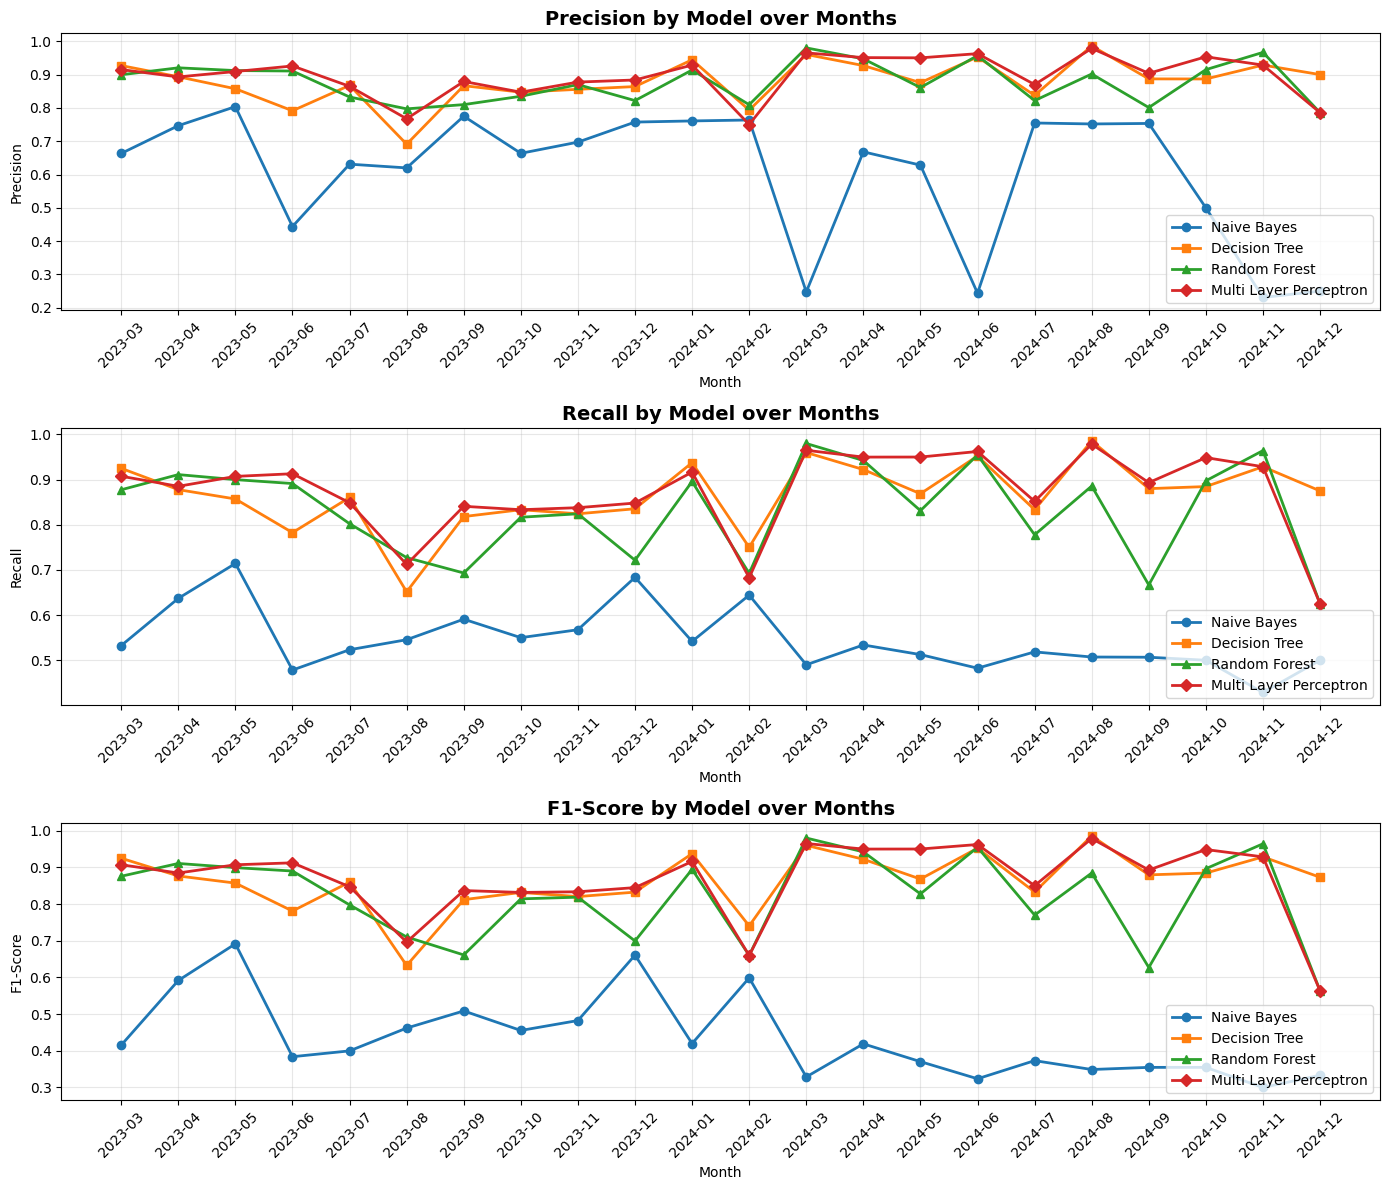


Chart saved to monthly_metrics_comparison.png


In [9]:
# 绘制不同模型在不同月份的指标折线图
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取所有模型名称
model_names = results_df['Model'].unique()
months = results_df['Month'].unique()

# 创建3个子图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

# 图1: Precision
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[0].plot(model_data['Month'], model_data['Precision'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[0].set_title('Precision by Model over Months', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(0, len(months)))
axes[0].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[0].grid(True, alpha=0.3)
# axes[0].set_ylim(0.8, 1.0)

# 图2: Recall
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[1].plot(model_data['Month'], model_data['Recall'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[1].set_title('Recall by Model over Months', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Recall')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(0, len(months)))
axes[1].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[1].grid(True, alpha=0.3)
# axes[1].set_ylim(0.8, 1.0)

# 图3: F1-Score
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[2].plot(model_data['Month'], model_data['F1'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[2].set_title('F1-Score by Model over Months', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('F1-Score')
axes[2].legend(loc='lower right')
axes[2].set_xticks(range(0, len(months)))
axes[2].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[2].grid(True, alpha=0.3)
# axes[2].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.savefig('/Data2/hxq/MalGuard/model_training/monthly_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to monthly_metrics_comparison.png")

In [10]:
# 分析几个性能下降明显的点，random forest模型，2023-09，2024-01，2024-02，2024-09
